Import Libraries such as Pandas, Datasets, Matplotlib.pyplot and Seaborn.

In [1]:
# Importing Libraries
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # To add percentage sign to y axis ticks

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

In [2]:
# In plots, FuncFormatter is to format x/y axis ticks as £K
from matplotlib.ticker import FuncFormatter
def pounds_k(x, pos):
    return f"£{x/1000:.0f}K"

# In scatterplots, adjustText prevents overlap of point labels
from adjustText import adjust_text

# What are the most optimum skills to learn for a data professional?

I filter the dataframe to show job postings from the United Kingdom whilst ensuring to create a copy of it also for data integrity. I also drop rows containing NA values in the column salary_year_avg as they are not relevant for my analysis.

In [3]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

df_UK = df_UK.dropna(subset="salary_year_avg")

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,Senior Satellite Analytics Data Engineer,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-08-10 13:34:53,False,False,United Kingdom,year,147500.0,NaN,Verisk,"[python, sql, nosql, mongodb, mongodb, elastic...","{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,Programmatic Data Specialist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 13:22:50,False,False,United Kingdom,year,109500.0,NaN,Publicis Groupe,"[excel, powerpoint, flow]","{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781461,Data Scientist,Data Scientist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-04-04 06:31:10,False,False,United Kingdom,year,88128.0,NaN,Kuda Technologies Ltd,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,Senior Data Scientist,"Belfast, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-28 06:14:36,False,False,United Kingdom,year,157500.0,NaN,Axiom,"[sql, r, python, aws, redshift, spark, gitlab,...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 06:36:08,True,False,United Kingdom,year,72900.0,NaN,Xiatech,"[html, python, css, javascript, sql, bigquery,...","{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ..."


## Analyse the data by aggregating it

As I have converted the values in column job_skills from string into list object, they are now 'explodable' and can be exploded into multiple rows. Below they are exploded and assigned to variable df_UK_exploded.

In [4]:
df_UK_exploded = df_UK.explode("job_skills")

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,python,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,numpy,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,pandas,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,scikit-learn,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,excel,"{'analyst_tools': ['excel', 'word', 'outlook']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,aws,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,pandas,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,flow,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,git,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."


I then pivot data by job skills to see how many jobs each skill contains and what is the median salary of all the jobs wherein there is mention of that skill. I assign the resultant table to variable df_UK_top_skills

In [11]:
df_UK_top_skills = (df_UK_exploded
                    .groupby("job_skills")["salary_year_avg"]
                    .agg(["count", "median"])
                    .sort_values(by="count", ascending=False)
                )

df_UK_top_skills

,count,median
job_skills,,
python,169,111175.0
sql,160,105300.0
aws,92,131723.5
excel,50,89100.0
tableau,47,111175.0
...,...,...
sharepoint,1,100500.0
terminal,1,53014.0
trello,1,89100.0


I then add a percentage column. This operation consists of 2 steps:
1. I add a a column called total_jobs. This is the number of jobs of df_UK calculated using the len() function.
2. I add a column called percentage which takes the value from the column count and divides it by the value in column total_jobs. The result is then multiplied by 100 to return the percentage.

I make a subset of the data which returns the top 10 skills using the .head() method.

In [17]:

df_UK_top_skills["total_jobs"] = len(df_UK)

df_UK_top_skills["percentage"] = (df_UK_top_skills["count"] / df_UK_top_skills["total_jobs"]) * 100

df_UK_top_skills

df_top_10 = df_UK_top_skills.head(10)

df_top_10

,count,median,total_jobs,percentage
job_skills,,,,
python,169,111175.0,287,58.885017
sql,160,105300.0,287,55.749129
aws,92,131723.5,287,32.055749
excel,50,89100.0,287,17.421603
tableau,47,111175.0,287,16.376307
spark,44,147500.0,287,15.331010
r,42,113360.5,287,14.634146
azure,39,131580.0,287,13.588850
gcp,33,132500.0,287,11.498258


## Plot the analysis on a scatterplot

I finally plot the subset of data on a scatterplot using Seaborn.
This is a multi-step operation.
1. Generate the scatterplot
2. Format the x and y axis ticks to include a percentage sign (%),  thousands K and pound sign (£). This is done using the mtick module.
3. Add datalabels for each point on the scatterplot. This is done using a for loop, the iterrows() function and the plt.text() function.
4. Ensure data labels do not overlap each other. This is using the adjust_text module.

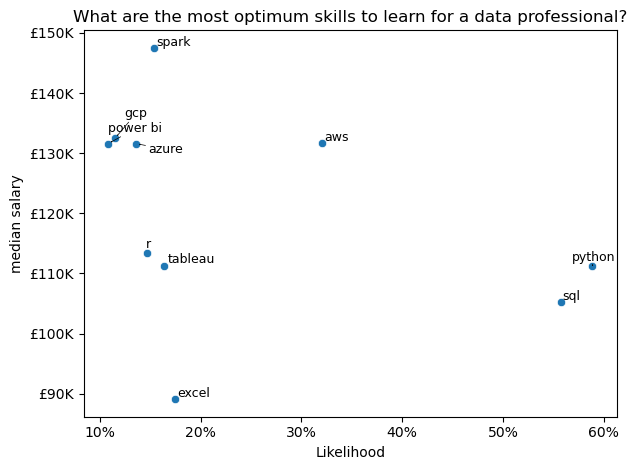

In [27]:
# 1. Generate the scatterplot
sns.scatterplot(
    data=df_top_10,
    x=df_top_10["percentage"],
    y=df_top_10["median"]
)

# 2. Format the x and y axis ticks to include a percentage sign (%),  thousands K and pound sign (£). This is done using the mtick module.
ax = plt.gca() # Get current axes

# Format Y-axis ticks to £K
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pounds_k))

# Format X-axis ticks to %
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# 3. Add datalabels for each point on the scatterplot.
# Create an empty list to store Matplotlib text objects for overlap adjustment
texts = [] 

# Loop through each row of the top 10 skills dataframe
# 'skill' receives the row index (skill name), 'row' receives the column data
for skill, row in df_top_10.iterrows():
    # Generate a text label on the chart and add it to our list
    texts.append(
        plt.text(
            x=row["percentage"], # X-coordinate: Position label based on x axis
            y=row["median"],     # Y-coordinate: Position label based on y axis
            s=skill,             # String: The actual text to display (the skill name)
            fontsize=9           # Font size: Adjusts the text scale on the plot
        )
    )


# 4. Ensure data labels do not overlap each other
# This is using adjust_text module
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle="->", color='black', lw=0.5) # Adds a pointer line if text moves too far
)

plt.title("What are the most optimum skills to learn for a data professional?")
plt.xlabel("Likelihood")
plt.ylabel("median salary")
plt.tight_layout();
